# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model as m       # I've put all the functions in a separate Python file

In [2]:
# parameters of the simulation
par={'N': 10,                    # side length of the squared lattice
     'p_self_link': 0,         # probability for each cell of having a self link
     'J_range': [-1,+1],                       # define the possible value for J.
     'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.5,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 2,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.8,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'T_initial': lambda x: 0+1*x,              # initial transfer function shape (here linear)
     'T_crossover_ratio': 0.2,                    # percentage of offspring to be generated by crossover + mutation (instead of only mutation)
     #'target_set': [0.0,1.0,1.0,0.0],
     'target_set': [-2,+2,+2,-2],
     #'input_set':[[0,0],[0,1],[1,0],[1,1]],
     'input_set':[[-2,-2],[-2,+2],[+2,-2],[+2,+2]],
     'n_iter': 200,
     'N_sol': 50}                       # number of solutions (individuals, networks) considered in the simulation

#nrd.seed(1234)

In [3]:
solutions, lmean, t_dist_mean, volume_mean = m.evolution(par,verb=2,gen_verb=False)

Iteration #0...
Mean loss: 2.3950985907469384
Mean target distance: 8.727260064290341
Mean volume: 1.0223144903581267
Iteration #10...
Mean loss: 0.58652365619241
Mean target distance: 1.5827963278401962
Mean volume: 0.8044042567084992
Iteration #20...
Mean loss: 0.6306892879309243
Mean target distance: 1.7193129911637461
Mean volume: 0.8042314049586777
Iteration #30...
Mean loss: 0.6003460660652854
Mean target distance: 1.690451568674564
Mean volume: 0.8042314049586777
Iteration #40...
Mean loss: 0.572194153218
Mean target distance: 1.5148869409700096
Mean volume: 0.8148913563922049
Iteration #50...
Mean loss: 0.6624485540375842
Mean target distance: 1.8102463102668784
Mean volume: 0.8042314049586778
Iteration #60...
Mean loss: 0.6925301012803919
Mean target distance: 2.0345824400341037
Mean volume: 0.8042314049586777
Iteration #70...
Mean loss: 0.6178376334647713
Mean target distance: 1.6845459904767506
Mean volume: 0.8042314049586777
Iteration #80...
Mean loss: 0.5639591761492366
Me

In [4]:
print(f'# parents: {int(np.floor(par['N_sol'] * par['reproduction_ratio'])-np.floor(par['N_sol'] * par['reproduction_ratio'])%2)}')

# parents: 40


In [5]:
s = copy.deepcopy(solutions)
losses = []
for n,sol in enumerate(s[:20]):
    print(f'Solution #{n}')
    loss,_,_ = m.compute_loss(sol,par,verb=True)
    losses.append(loss)
    print(f'loss:{loss}')

Solution #0
Input: [-2, -2] -> Output: -0.41330784321460934
Target distance:0.025175920004042746
Volume cost:1.7485144457345807e-06
Input: [-2, 2] -> Output: -1.38134637190235
Target distance:0.11433503286777186
Volume cost:1.7485144457345807e-06
Input: [2, -2] -> Output: -0.45713698212261367
Target distance:0.06037522148914625
Volume cost:1.7485144457345807e-06
Input: [2, 2] -> Output: -1.3632875035996768
Target distance:0.004054028030723316
Volume cost:1.7485144457345807e-06
loss:0.2028695142298537
Solution #1
Input: [-2, -2] -> Output: -4.99729148850526
Target distance:0.08983756267066076
Volume cost:1.7485144457345807e-06
Input: [-2, 2] -> Output: -1.3828327611612605
Target distance:0.1144355748998592
Volume cost:1.7485144457345807e-06
Input: [2, -2] -> Output: -6.206480421876366
Target distance:0.6734632091464009
Volume cost:1.7485144457345807e-06
Input: [2, 2] -> Output: -0.8924416069843111
Target distance:0.012266855939394953
Volume cost:1.7485144457345807e-06
loss:0.39367639066

In [6]:
print(f'Mean final loss: {np.mean(np.array(losses) < 100)}')

Mean final loss: 1.0


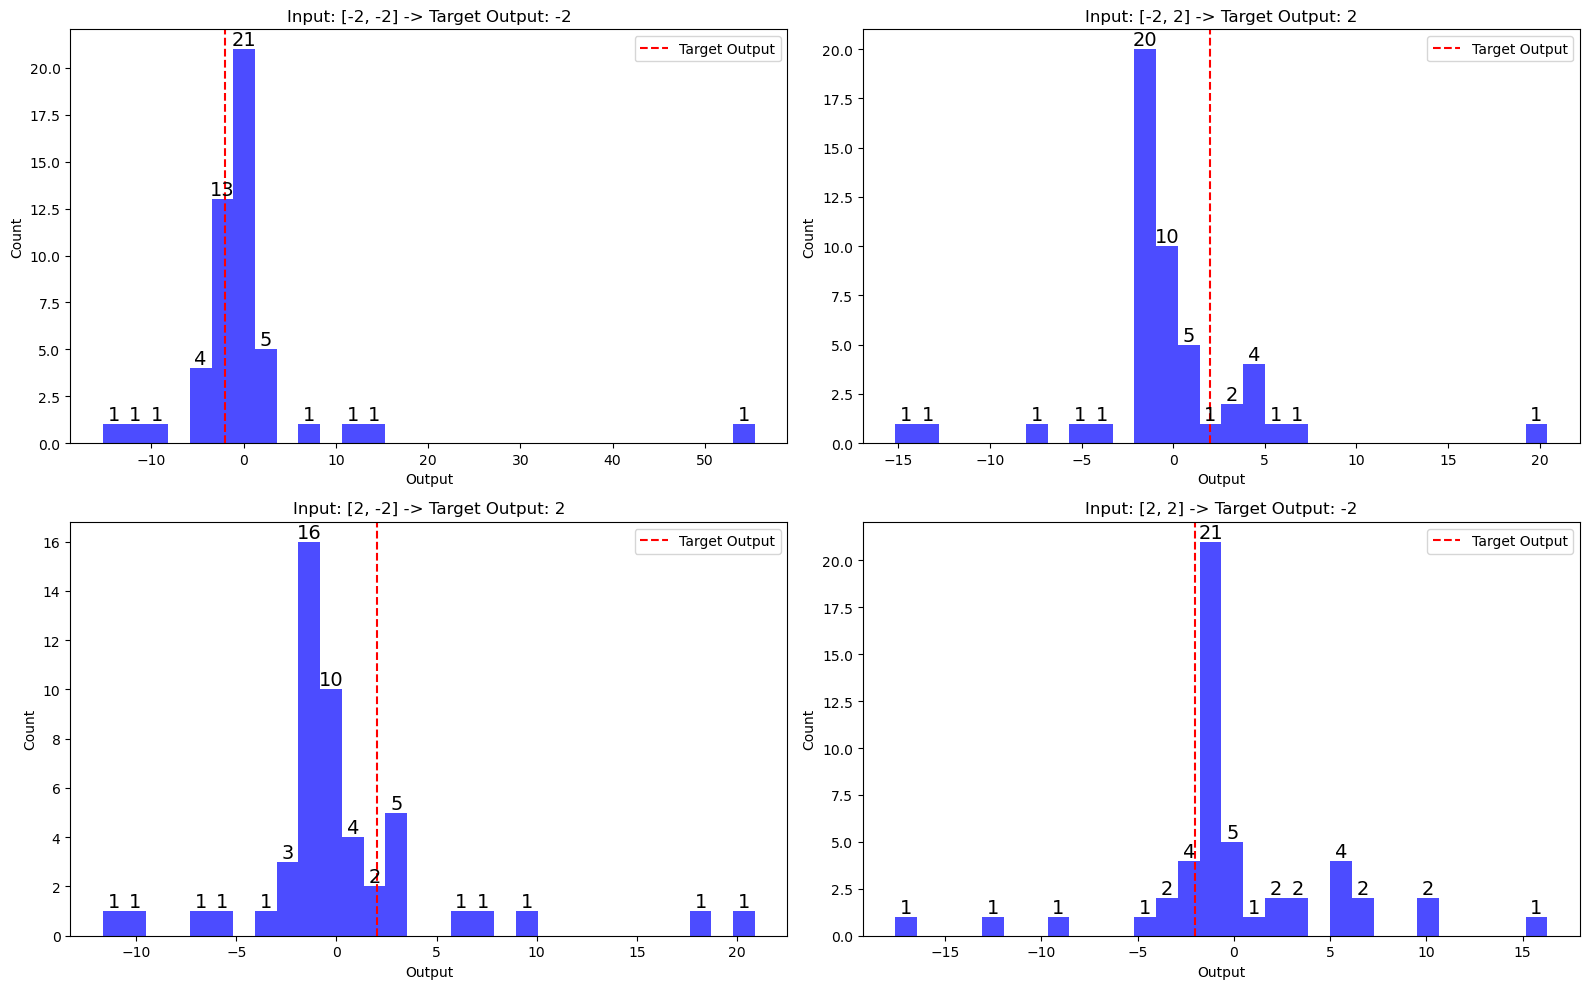

In [7]:
outputs = np.zeros((len(solutions),len(par['input_set'])))
for n,sol in enumerate(solutions):
    for i,input in enumerate(par['input_set']):
        output = m.ff(input,sol,par)
        outputs[n,i] = output

fig, axes = plt.subplots(2, len(par['input_set'])//2, figsize=(16, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.hist(outputs[:, i], bins=30, alpha=0.7, color='b')
    ax.set_title(f'Input: {par["input_set"][i]} -> Target Output: {par['target_set'][i]}')
    ax.set_xlabel('Output')
    ax.set_ylabel('Count')
    ax.axvline(par['target_set'][i], label='Target Output', color='r',linestyle='--')
    #ax.set_xticks(list(ax.get_xticks()) + [par['target_set'][i]])
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        (patch.get_x() + patch.get_width() / 2, height), 
                        ha='center', va='bottom', fontsize=14)
    ax.legend()
plt.tight_layout()
plt.show()

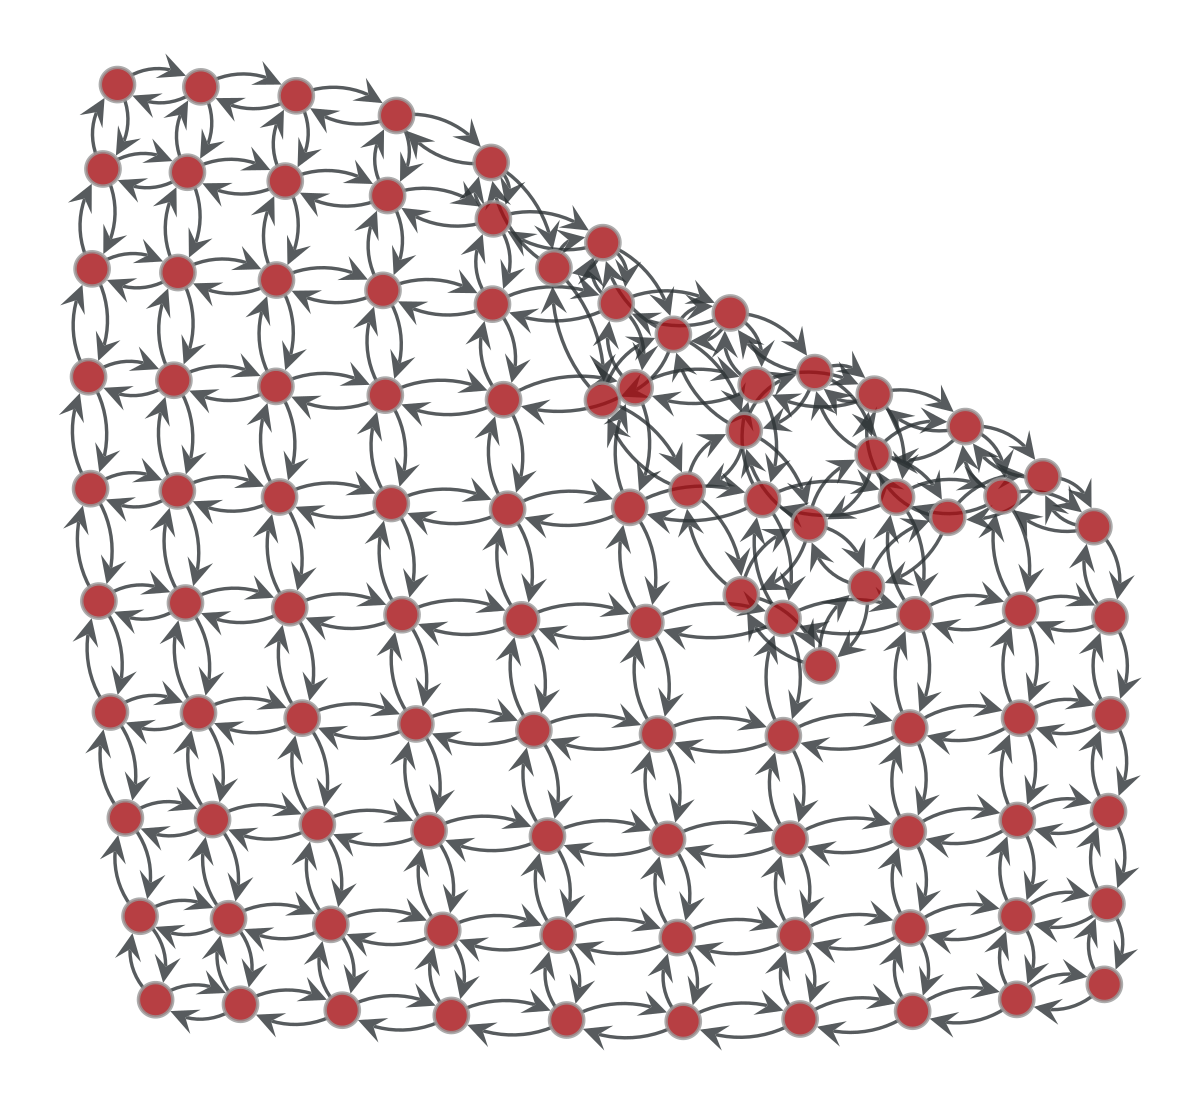

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fb65d3c1310, at 0x7fb6532794e0>

In [8]:
graph_draw(s[0].G)

In [9]:
print(f'Percentage of links over the maximum possible:{np.sum(s[0].C)/s[0].C.shape[0]**2}')

Percentage of links over the maximum possible:0.036


In [10]:
np.array([sol.loss for sol in s])

array([0.1837547 , 0.36330348, 0.17030914, 0.43440333, 0.4698337 ,
       0.18865496, 0.20035704, 0.20910598, 2.40451097, 0.35476187,
       0.21047949, 0.21345519, 0.24965074, 0.18478893, 0.21922051,
       0.39286102, 1.60837348, 0.15347259, 0.2070157 , 2.59384138,
       0.34919171, 1.81574765, 0.17936104, 0.13679639, 0.19056708,
       0.18778265, 1.89399126, 1.8269021 , 0.20241109, 1.59191017,
       0.2018385 , 2.58862198, 0.34237498, 0.18422934, 0.19779475,
       2.52446468, 0.17971331, 0.19114906, 0.24626154, 0.41538706,
       0.23734434, 0.15524429, 0.21836861, 1.88266457, 0.17040154,
       0.13119459, 0.20228992, 0.21330315, 0.19626862, 1.86018465])

In [11]:
for input in par['input_set']:
    output = m.ff(input,s[0],par)
    print(f'Input:{input} -> Output:{output}')

Input:[-2, -2] -> Output:-0.35727355529723015
Input:[-2, 2] -> Output:-1.325297681250103
Input:[2, -2] -> Output:-0.4938933500034618
Input:[2, 2] -> Output:-1.158233930586754


In [12]:
def plot_T(T:np.ndarray,par:dict) -> None:
    """Function to plot the shape of the transfer function given the Fourier coefficients.

    Args:
        T (np.ndarray): array of the Fourier coefficients of A SINGLE cell.
        par (dict): simulation parameters.
    """
    f_n = np.fft.irfft(T)
    coeff = np.polyfit(par['x_n'],f_n,3)    # fit the series of function value with a polynomial of degree up to 5
    new_fun = np.poly1d(coeff)                      # generate the new functional from the fit results
    x = np.linspace(min(par['x_n']),max(par['x_n']),1000)
    x = np.linspace(-10,10,1000)
    plt.plot(x,new_fun(x))
    plt.grid()
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Transfer function')
    plt.show()

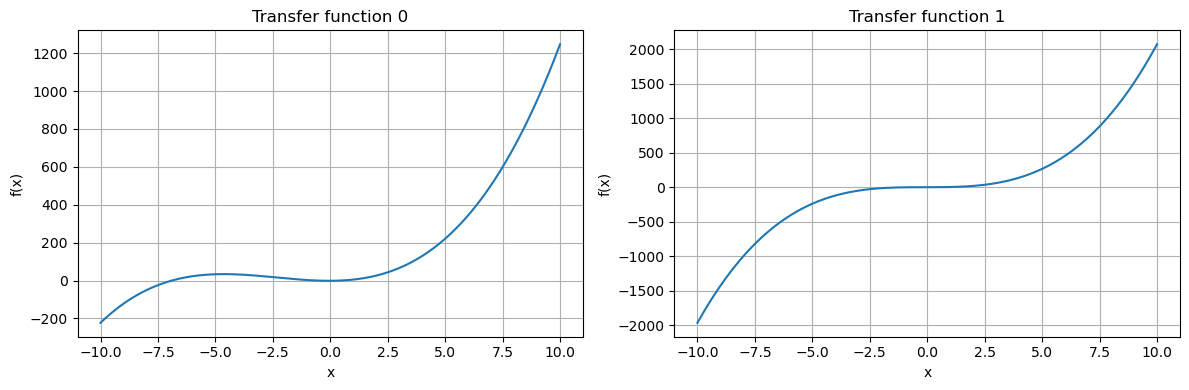

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    f_n = np.fft.irfft(solutions[0].T[i])
    coeff = np.polyfit(par['x_n'], f_n, 3)
    new_fun = np.poly1d(coeff)
    x = np.linspace(min(par['x_n']), max(par['x_n']), 1000)
    x = np.linspace(-10, 10, 1000)
    axes[i].plot(x, new_fun(x))
    axes[i].grid()
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('f(x)')
    axes[i].set_title(f'Transfer function {i}')
plt.tight_layout()
plt.show()

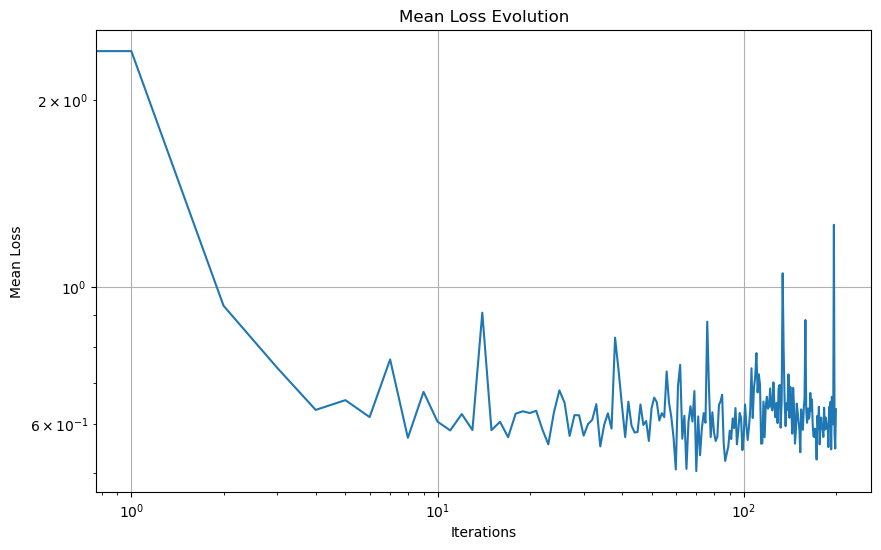

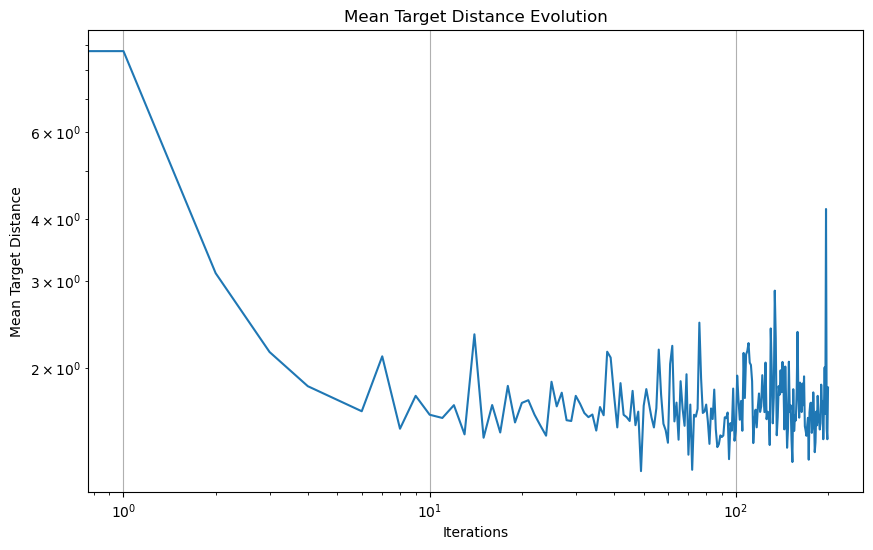

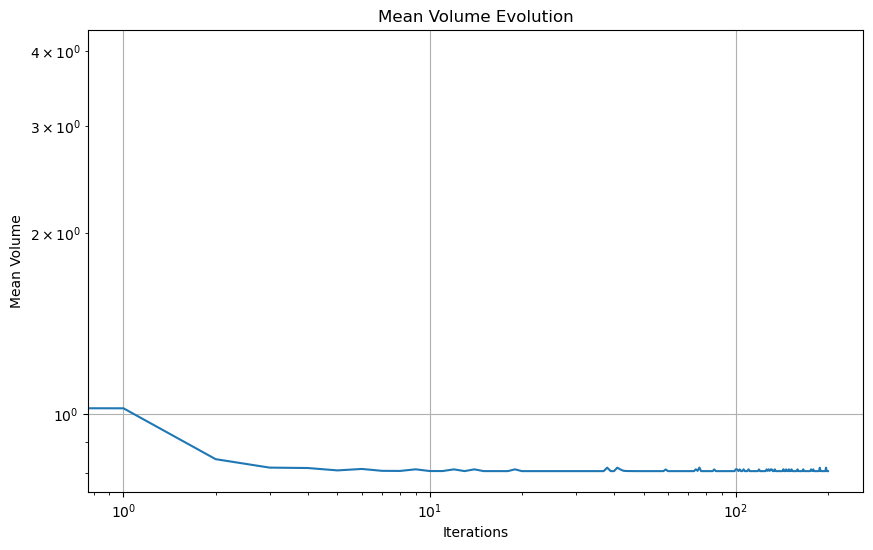

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(lmean)
plt.title('Mean Loss Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Loss')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_dist_mean)
plt.title('Mean Target Distance Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Target Distance')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(volume_mean)
plt.title('Mean Volume Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Volume')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()